<div style="border-left:6px solid #2a78d6;padding:14px 20px;background:#f4f8fd;border-radius:6px">
<p style="margin:0;color:#52514e;font-size:13px">Data Analytics Básico · Módulo 14 — Análisis avanzado</p>
<h1 style="margin:6px 0 0 0;color:#0b0b0b">14. Fundamentos de Modelado Predictivo</h1>
<p style="margin:8px 0 0 0;color:#52514e">El salto del análisis descriptivo (<em>qué pasó</em>) al predictivo (<em>qué va a pasar</em>): el flujo mínimo y profesional para construir, evaluar y no auto-engañarte con un primer modelo.</p>
</div>

> ### Antes de empezar
>
> Hasta ahora describiste y exploraste datos. Aquí das el salto al **modelado predictivo**: enseñarle a un algoritmo a estimar un resultado (¿este cliente se irá?) a partir de datos históricos. No es magia — es un flujo con pasos claros, y este notebook te enseña ese flujo **y sus trampas** (por qué un modelo con 85% de acierto puede ser inútil).
>
> Usaremos scikit-learn sobre un caso de *churn* (abandono de clientes). Ejecuta cada celda y presta atención a las **métricas**: son las que te dicen si el modelo sirve o solo lo parece.

Cargamos las librerías:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

sns.set_theme(style='whitegrid')
np.random.seed(42)
pd.set_option('display.max_columns', None)

print('Notebook 14 listo: Fundamentos de Modelado Predictivo')

Notebook 14 listo: Fundamentos de Modelado Predictivo


## Introducción al Modelado Predictivo

### ¿Qué es?
El modelado predictivo es una metodología para estimar resultados futuros usando patrones aprendidos desde datos históricos.

No es "adivinar": es construir una función que relacione variables de entrada (features) con una salida esperada (target), y medir qué tan bien generaliza en datos no vistos.

### ¿Para qué sirve?
Te permite anticiparte a escenarios de negocio:
- detectar clientes con alto riesgo de abandono
- estimar demanda o ventas futuras
- priorizar casos para equipos comerciales u operativos
- asignar recursos con mejor criterio

En la práctica, reduce decisiones basadas solo en intuición.

### ¿Cómo se usa?
El flujo mínimo profesional que aprenderás aquí es:
1. Definir problema de negocio y objetivo analítico
2. Preparar dataset y separar target/features
3. Dividir train/validation/test
4. Construir baseline para comparar
5. Entrenar primer modelo supervisado
6. Evaluar y documentar hallazgos/limitaciones

## 1. Definición del Problema

### ¿Qué es?
Es convertir una necesidad del negocio en una pregunta analítica clara, medible y accionable.

Ejemplo:
- Necesidad de negocio: reducir pérdida de clientes
- Pregunta analítica: ¿qué clientes tienen mayor probabilidad de abandonar en los próximos meses?

### ¿Para qué sirve?
Define:
- qué variable vas a predecir
- con qué horizonte temporal
- para qué decisión se usará el resultado

Sin esta definición, puedes construir un modelo técnicamente correcto pero inútil para negocio.

### ¿Cómo se usa?
Caso didáctico de este notebook:
- Industria: fintech
- Objetivo: anticipar churn
- Stakeholder: equipo de retención
- Acción esperada: priorizar clientes para campañas preventivas

In [2]:
# ------------------------------------------------------
# Generacion de dataset sintetico para caso de churn
# ------------------------------------------------------
# Este bloque crea datos "realistas" para practicar el flujo
# completo de modelado sin depender de archivos externos.
n = 4000

df = pd.DataFrame({
    'antiguedad_meses': np.random.randint(1, 61, size=n),
    'uso_mensual_horas': np.random.gamma(shape=2.0, scale=8.0, size=n),
    'tickets_soporte': np.random.poisson(lam=1.8, size=n),
    'monto_mensual': np.random.normal(45, 12, size=n).clip(12, 120),
    'metodo_pago': np.random.choice(['tarjeta', 'transferencia', 'efectivo'], size=n, p=[0.65, 0.25, 0.10]),
    'plan': np.random.choice(['basico', 'plus', 'premium'], size=n, p=[0.55, 0.30, 0.15]),
    'region': np.random.choice(['norte', 'centro', 'sur'], size=n, p=[0.35, 0.45, 0.20])
})

# Construimos una probabilidad de churn con una funcion logistica.
# La idea es simular relaciones plausibles:
# - mas tickets => mayor riesgo
# - mayor antiguedad/uso => menor riesgo
# - ciertos planes/metodos => diferencias de riesgo
logit = (
    -1.8
    + 0.45 * (df['tickets_soporte'] >= 3).astype(int)
    - 0.02 * df['antiguedad_meses']
    - 0.03 * df['uso_mensual_horas']
    + 0.015 * df['monto_mensual']
    + 0.25 * (df['metodo_pago'] == 'efectivo').astype(int)
    + 0.20 * (df['plan'] == 'basico').astype(int)
    + np.random.normal(0, 0.5, size=n)
)

proba = 1 / (1 + np.exp(-logit))
df['abandono'] = np.random.binomial(1, proba)

print('Dimensión:', df.shape)
print('Tasa de abandono: {:.2%}'.format(df['abandono'].mean()))
df.head()

Dimensión: (4000, 8)
Tasa de abandono: 14.42%


,antiguedad_meses,uso_mensual_horas,tickets_soporte,monto_mensual,metodo_pago,plan,region,abandono
0,39,8.620692,0,67.641717,tarjeta,basico,centro,0
1,52,4.107727,1,32.253638,tarjeta,premium,norte,1
2,29,18.979798,1,66.571365,tarjeta,plus,centro,0
3,15,11.046765,1,43.123756,tarjeta,premium,centro,0
4,43,3.783460,1,42.968895,tarjeta,plus,norte,0


## 2. Variable Objetivo y Features

### ¿Qué es?
- Variable objetivo (y): resultado a predecir (en este caso, abandono)
- Features (X): variables que ayudan a explicar/predecir ese resultado

### ¿Para qué sirve?
Esta separación es esencial porque evita confusiones metodológicas.

Si mezclas objetivo y features, o incluyes columnas incorrectas, puedes introducir sesgos o fugas de información.

### ¿Cómo se usa?
1. Definir explícitamente el target
2. Separar X e y
3. Revisar tipos de datos (numéricos y categóricos)
4. Preparar preprocesamiento acorde a cada tipo de feature

In [3]:
target = 'abandono'
X = df.drop(columns=[target])
y = df[target]

numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas = X.select_dtypes(exclude=['number']).columns.tolist()

print('Target:', target)
print('Features numéricas:', numericas)
print('Features categóricas:', categoricas)

Target: abandono
Features numéricas: ['antiguedad_meses', 'uso_mensual_horas', 'tickets_soporte', 'monto_mensual']
Features categóricas: ['metodo_pago', 'plan', 'region']


## 3. Separación Train, Validation y Test

### ¿Qué es?
Es una estrategia para evaluar modelos de manera honesta.

- Train: donde el modelo aprende
- Validation: donde ajustamos decisiones (ej. hiperparámetros)
- Test: evaluación final, una sola vez

### ¿Para qué sirve?
Evita sobreajuste y expectativas irreales.

Si evalúas con los mismos datos de entrenamiento, el resultado suele verse mejor de lo que realmente será en producción.

### ¿Cómo se usa?
En este notebook usamos 70/15/15 y stratify para preservar la proporción de clases.
Esto hace la comparación más estable y realista.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)
print('Tasa churn train: {:.2%}'.format(y_train.mean()))
print('Tasa churn val:   {:.2%}'.format(y_val.mean()))
print('Tasa churn test:  {:.2%}'.format(y_test.mean()))

Train: (2800, 7) Validation: (600, 7) Test: (600, 7)
Tasa churn train: 14.43%
Tasa churn val:   14.50%
Tasa churn test:  14.33%


## 4. Baseline del Modelo

### ¿Qué es?
Un baseline es la referencia mínima contra la que se comparan modelos más elaborados.

En clasificación, una opción común es predecir siempre la clase mayoritaria.

### ¿Para qué sirve?
Sirve para responder una pregunta crítica:
"¿Mi modelo realmente aprende algo útil o solo parece complejo?"

Si no superas el baseline, no hay evidencia de valor adicional.

### ¿Cómo se usa?
Aplicamos DummyClassifier y medimos sus métricas en validación.
Luego comparamos contra el modelo supervisado que construiremos después.

In [5]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train[numericas], y_train)
pred_base = baseline.predict(X_val[numericas])

acc_base = accuracy_score(y_val, pred_base)
f1_base = f1_score(y_val, pred_base, zero_division=0)

print('Baseline accuracy: {:.3f}'.format(acc_base))
print('Baseline F1: {:.3f}'.format(f1_base))

Baseline accuracy: 0.855
Baseline F1: 0.000


## 5. Primer Modelo Supervisado

### ¿Qué es?
Entrenaremos una Regresión Logística con preprocesamiento integrado en pipeline.

### ¿Para qué sirve?
Es un excelente primer modelo porque:
- funciona bien en clasificación binaria
- es rápido de entrenar
- permite trazabilidad del flujo de datos
- suele ser un baseline fuerte frente a modelos más complejos

### ¿Cómo se usa?
1. Escalar variables numéricas
2. Codificar categóricas con one-hot
3. Entrenar modelo sobre train
4. Evaluar en validation con métricas clave (accuracy, precision, recall, F1, ROC AUC)

Importante: en churn, recall suele ser especialmente relevante porque perder un cliente no detectado puede ser costoso.

In [6]:
# ------------------------------------------------------
# Pipeline de modelado: preprocesamiento + clasificador
# ------------------------------------------------------
preproceso = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas)
    ]
)

modelo = Pipeline(steps=[
    ('preproceso', preproceso),
    ('clf', LogisticRegression(max_iter=1000))
])

# Entrenamos en train
modelo.fit(X_train, y_train)

# Evaluamos en validation para decidir ajustes antes de test
pred_val = modelo.predict(X_val)
proba_val = modelo.predict_proba(X_val)[:, 1]

metricas = {
    'accuracy': accuracy_score(y_val, pred_val),
    'precision': precision_score(y_val, pred_val, zero_division=0),
    'recall': recall_score(y_val, pred_val, zero_division=0),
    'f1': f1_score(y_val, pred_val, zero_division=0),
    'roc_auc': roc_auc_score(y_val, proba_val)
}

pd.Series(metricas).round(3)

,0
accuracy,0.855
precision,0.000
recall,0.000
f1,0.000
roc_auc,0.711


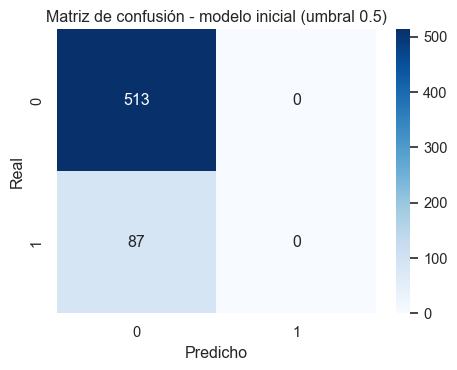

In [7]:
cm = confusion_matrix(y_val, pred_val)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - modelo inicial (umbral 0.5)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 5.1 Diagnóstico: ¿por qué recall = 0?

El modelo alcanzó **85.5% de accuracy**… pero **recall = 0**. Eso significa que **no detectó ni un solo cliente en riesgo de abandono**. Para el equipo de retención, un modelo así es inútil por más que el accuracy parezca alto.

**¿Qué pasó?** Tres cosas conectadas:

- **Clases desbalanceadas:** solo ~14% de los clientes abandonan. La clase "no abandona" domina el dataset.
- **La trampa del accuracy:** si el modelo predice *"nadie abandona"* para todos, acierta el 85.5% de las veces (todos los que efectivamente se quedan). Optimizar el accuracy lo empuja a esa solución perezosa.
- **El umbral de 0.5:** por defecto se predice "abandono" solo si la probabilidad estimada supera 0.5. Con datos desbalanceados, el modelo casi nunca asigna probabilidades tan altas a la clase minoritaria.

> **Pista clave:** el **ROC AUC ≈ 0.71** (bastante mayor que 0.5) nos dice que el modelo **sí distingue** entre quién abandona y quién no. El problema no es el modelo: es la **regla de decisión**.

## 5.2 La solución: reequilibrar las clases

`scikit-learn` permite decirle al modelo que **ambas clases importan por igual**, aunque una sea rara, con el parámetro `class_weight='balanced'`. Internamente penaliza más los errores sobre la clase minoritaria (el churn), obligando al modelo a prestarle atención.

Es la solución más simple y sin dependencias extra. *(Otra alternativa común es **remuestrear** los datos —por ejemplo con SMOTE—, pero requiere librerías adicionales; para empezar, `class_weight` es suficiente.)*

Reentrenamos exactamente el mismo pipeline, cambiando solo ese parámetro:

In [8]:
# Mismo pipeline, pero indicando que ambas clases importan por igual
modelo_bal = Pipeline(steps=[
    ('preproceso', preproceso),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

modelo_bal.fit(X_train, y_train)

pred_val_bal = modelo_bal.predict(X_val)
proba_val_bal = modelo_bal.predict_proba(X_val)[:, 1]

metricas_bal = {
    'accuracy': accuracy_score(y_val, pred_val_bal),
    'precision': precision_score(y_val, pred_val_bal, zero_division=0),
    'recall': recall_score(y_val, pred_val_bal, zero_division=0),
    'f1': f1_score(y_val, pred_val_bal, zero_division=0),
    'roc_auc': roc_auc_score(y_val, proba_val_bal)
}

# Comparacion lado a lado: modelo inicial vs modelo con balanceo
comparacion = pd.DataFrame({
    'modelo_inicial': metricas,
    'con_balanceo': metricas_bal
}).round(3)

comparacion

,modelo_inicial,con_balanceo
accuracy,0.855,0.618
precision,0.000,0.225
recall,0.000,0.667
f1,0.000,0.336
roc_auc,0.711,0.712


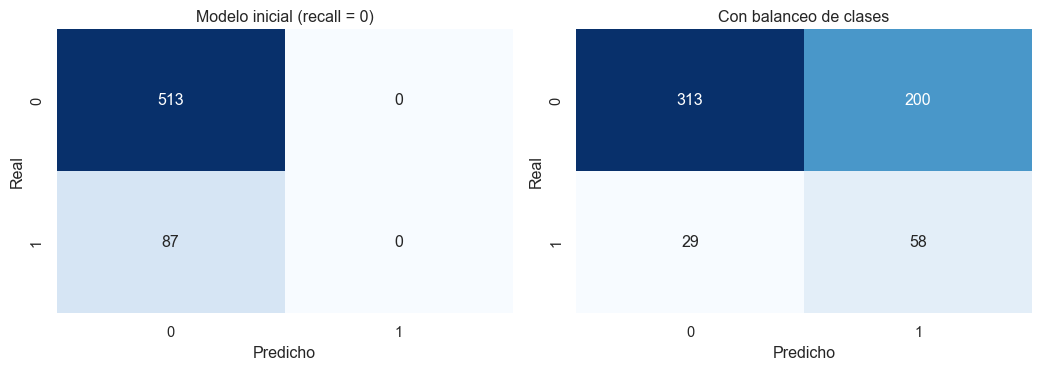

In [9]:
# La matriz de confusion muestra el cambio: el modelo ya detecta churn real
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, titulo in [
    (axes[0], pred_val, 'Modelo inicial (recall = 0)'),
    (axes[1], pred_val_bal, 'Con balanceo de clases')
]:
    sns.heatmap(confusion_matrix(y_val, pred), annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(titulo)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

### Qué cambió (y qué no)

- **Recall subió de 0 a ~0.67:** ahora el modelo detecta dos de cada tres clientes que realmente abandonan. Ese es el objetivo del negocio.
- **Precision bajó:** a cambio, algunas alarmas son falsas (clientes marcados como riesgo que no se irían). Es el **trade-off precision/recall**: para no perder churners, aceptamos revisar algunos casos de más.
- **El ROC AUC casi no cambió (~0.71):** confirma lo que sospechábamos — la *capacidad de ordenar* clientes por riesgo era la misma. Solo cambiamos la **regla de decisión**, no la inteligencia del modelo.

En churn este intercambio suele valer la pena: es más barato contactar a algunos clientes de más que perder, sin verlo venir, a uno que se iba. A partir de aquí usamos `modelo_bal` como nuestro modelo de trabajo.

## 6. Data Leakage: Error Común

### ¿Qué es?
Data leakage ocurre cuando el modelo recibe información que, en la realidad, no estaría disponible al momento de predecir.

Ejemplo: variables creadas después del evento (como una gestión de cancelación posterior al abandono).

### ¿Para qué sirve detectarlo?
Porque puede generar métricas artificialmente altas y decisiones equivocadas en producción.

El modelo "parece brillante" en pruebas, pero falla cuando se usa en el mundo real.

### ¿Cómo se evita?
1. Entender el proceso temporal del negocio (qué ocurre antes y después)
2. Excluir columnas con información futura
3. Definir claramente el momento de predicción
4. Revisar variables sospechosas con stakeholders

En el bloque siguiente veremos una demostración didáctica de este problema.

In [10]:
# Ejemplo didactico: variable de fuga (no usar en produccion)
df_leak = df.copy()
df_leak['ticket_cancelacion'] = np.where(df_leak['abandono'] == 1, 1, np.random.binomial(1, 0.03, size=len(df_leak)))

X_leak = df_leak.drop(columns=['abandono'])
y_leak = df_leak['abandono']

Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_leak, y_leak, test_size=0.2, random_state=42, stratify=y_leak)

num_l = X_leak.select_dtypes(include=['number']).columns.tolist()
cat_l = X_leak.select_dtypes(exclude=['number']).columns.tolist()

pipe_leak = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_l),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_l)
    ])),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe_leak.fit(Xl_train, yl_train)
pred_leak = pipe_leak.predict(Xl_test)

print('Accuracy con leakage: {:.3f}'.format(accuracy_score(yl_test, pred_leak)))
print('Recall con leakage:   {:.3f}'.format(recall_score(yl_test, pred_leak, zero_division=0)))
print('Nota: métricas casi perfectas suelen delatar una fuga de información.')

Accuracy con leakage: 0.971
Recall con leakage:   1.000
Nota: métricas casi perfectas suelen delatar una fuga de información.


## 7. Evaluación Final en Test

Usamos el conjunto de test solo una vez, al final, para estimar el desempeño esperado en producción.

In [11]:
# Evaluamos el modelo corregido (con balanceo) una sola vez en test
pred_test = modelo_bal.predict(X_test)
proba_test = modelo_bal.predict_proba(X_test)[:, 1]

resultados_test = pd.Series({
    'accuracy_test': accuracy_score(y_test, pred_test),
    'precision_test': precision_score(y_test, pred_test, zero_division=0),
    'recall_test': recall_score(y_test, pred_test, zero_division=0),
    'f1_test': f1_score(y_test, pred_test, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test, proba_test)
}).round(3)

resultados_test

,0
accuracy_test,0.563
precision_test,0.176
recall_test,0.558
f1_test,0.268
roc_auc_test,0.613


## 8. Ejercicio Práctico Integrador

### ¿Qué es?
Una práctica corta para consolidar el ciclo completo de modelado.

### ¿Para qué sirve?
Refuerza tres habilidades clave:
- crear features con sentido de negocio
- validar si aportan mejora real
- comunicar una conclusión comprensible para stakeholders

### Instrucciones
1. Crea una nueva feature: uso_por_antiguedad = uso_mensual_horas / antiguedad_meses
2. Reentrena el modelo
3. Compara F1 en validación frente al modelo anterior
4. Escribe una conclusión de negocio en 3 líneas

Pista: no toda nueva variable mejora el modelo; lo importante es medir y justificar.

In [12]:
df_ej = df.copy()
df_ej['uso_por_antiguedad'] = df_ej['uso_mensual_horas'] / df_ej['antiguedad_meses'].replace(0, 1)

X_ej = df_ej.drop(columns=['abandono'])
y_ej = df_ej['abandono']

Xe_train, Xe_val, ye_train, ye_val = train_test_split(
    X_ej, y_ej, test_size=0.25, random_state=42, stratify=y_ej
)

num_e = X_ej.select_dtypes(include=['number']).columns.tolist()
cat_e = X_ej.select_dtypes(exclude=['number']).columns.tolist()

pipe_ej = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_e),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_e)
    ])),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe_ej.fit(Xe_train, ye_train)
pred_ej = pipe_ej.predict(Xe_val)

print('F1 ejercicio (con feature nueva): {:.3f}'.format(f1_score(ye_val, pred_ej, zero_division=0)))
print('Compáralo con el F1 en validación del modelo con balanceo (celda anterior).')
print('Completa la conclusión de negocio en una celda markdown adicional.')

F1 ejercicio (con feature nueva): 0.302
Compáralo con el F1 en validación del modelo con balanceo (celda anterior).
Completa la conclusión de negocio en una celda markdown adicional.


## Glosario de referencia

| Concepto | Qué es |
|---|---|
| Modelo supervisado | Aprende de ejemplos etiquetados (X → y) |
| Features (X) / Target (y) | Variables de entrada / lo que se predice |
| Train / Validation / Test | Aprender / ajustar / evaluar una sola vez |
| Baseline | Referencia mínima (ej. predecir la clase mayoritaria) |
| Clases desbalanceadas | Una clase es mucho más frecuente que otra |
| `class_weight='balanced'` | Le dice al modelo que ambas clases importan igual |
| Accuracy | % de aciertos totales (engaña con desbalance) |
| Precision / Recall | Calidad / cobertura de los positivos |
| Matriz de confusión | Aciertos y errores por clase |
| Data leakage | Usar info no disponible al predecir → métricas infladas |

## Cierre

En este notebook aprendiste:
- El flujo base de modelado predictivo (definir problema, features, splits, baseline, modelo, evaluación)
- Por qué un accuracy alto puede esconder un modelo inútil cuando las clases están **desbalanceadas**
- Cómo diagnosticar el problema (recall = 0, matriz de confusión) y resolverlo con `class_weight='balanced'`
- El **trade-off precision/recall**: para no perder churners aceptamos algunas falsas alarmas
- El riesgo de **data leakage** y cómo delata métricas demasiado buenas

Siguiente paso recomendado: notebook 15 para comparar modelos de regresión y clasificación en escenarios concretos.

---
<p style="color:#898781;font-size:12px">Data Analytics Básico · Módulo 14 — Análisis avanzado</p>